In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import dabest
from pathlib import Path
import sys

sys.path.append("../ec-tracking-analysis_2025/")

from src.io import read_parameters

In [3]:
# read parameters and key file

parameter_file = "/media/jpa/Volume/MDC/MDC_data/ec_tracking/trial/parameters_test_set.yml"
parameters = read_parameters(parameter_file)

key_file_path = parameters["key_file"]
key_file = pd.read_csv(key_file_path)

print("key file columns:", key_file.columns)
print("key file conditions:", key_file["condition"].unique())

key file columns: Index(['experimentID', 'filename', 'color', 'treatment_old', 'treatment',
       'condition', 'frame_per_hour', 'date'],
      dtype='object')
key file conditions: ['Flow-siRNA' 'Stat-siRNA']


In [4]:
# parameter_file  = "../local/parameters.yml"
# parameters = read_parameters(parameter_file)   

# base_folder = parameters["base_folder"]
# tracking_data_files = parameters["tracking_data"]
# data_exclude = parameters["data_exclude"]
output_folder = Path(parameters["output_folder"])
tracking_data_path = output_folder.joinpath("speed_data")

# single_time_point_evaluation = parameters["single_time_point_evaluation"]

interval = parameters["time_lag"]

errorbar = ("ci", 95)

plt.rcParams.update({'font.size': 14})
interval = parameters["time_lag"]

subsample_n = 10  # for speed up of draft plotting
subsample_frac = 0.1  # for speed up of draft plotting

In [5]:
migration_speed_df = pd.DataFrame()

for index, row in key_file.iterrows():
    print("processing", row["condition"])
    #tracking_data_file = tracking_data_path + row["filename"]
    tracking_data_file = output_folder.joinpath(
        "speed_data",
        "migration_speed_df_%s_%s_%s.csv" % (row["treatment"], row["color"], row["experimentID"])
    )
    tracking_data = pd.read_csv(str(tracking_data_file))

    tracking_data['color'] = row['color']
    tracking_data['treatment'] = row['treatment']
    tracking_data['experimentID'] = row['experimentID']

    if migration_speed_df.empty:
        migration_speed_df = tracking_data
    else:
        migration_speed_df = pd.concat([migration_speed_df, tracking_data], ignore_index=True)

#migration_speed_df = migration_speed_df[migration_speed_df["time_lag"] == interval]
migration_speed_df

processing Flow-siRNA
processing Flow-siRNA
processing Stat-siRNA
processing Flow-siRNA


,TRACK_ID,POSITION_X,POSITION_Y,POSITION_T,FRAME,ORIGIN_X,ORIGIN_Y,step_size,step_size_x,step_size_y,...,vel_y_mu_per_h,phi,lag_used,filename,condition,time_in_h,time_from_start_h,color,treatment,experimentID
0,2036,1518.0,2452.0,0.0,0,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,0,tracking_data_siCtrl+highVEGF-Flow_black_D2_re...,Flow-siRNA,0.0,0.0,black,siCtrl+highVEGF-Flow,D2_rep1
1,2036,1517.0,2450.0,360.0,1,-1.0,-2.0,2.236,-1.0,-2.0,...,-20.000,-63.435,1,tracking_data_siCtrl+highVEGF-Flow_black_D2_re...,Flow-siRNA,0.1,0.1,black,siCtrl+highVEGF-Flow,D2_rep1
2,2036,1517.0,2450.0,720.0,2,-1.0,-2.0,2.236,-1.0,-2.0,...,-10.000,-63.435,2,tracking_data_siCtrl+highVEGF-Flow_black_D2_re...,Flow-siRNA,0.2,0.2,black,siCtrl+highVEGF-Flow,D2_rep1
3,2036,1516.0,2450.0,1080.0,3,-2.0,-2.0,2.828,-2.0,-2.0,...,-6.667,-45.000,3,tracking_data_siCtrl+highVEGF-Flow_black_D2_re...,Flow-siRNA,0.3,0.3,black,siCtrl+highVEGF-Flow,D2_rep1
4,2036,1519.0,2448.0,1440.0,4,1.0,-4.0,4.123,1.0,-4.0,...,-10.000,-104.036,4,tracking_data_siCtrl+highVEGF-Flow_black_D2_re...,Flow-siRNA,0.4,0.4,black,siCtrl+highVEGF-Flow,D2_rep1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3612736,7960,1965.0,2604.0,77760.0,216,2.0,-2.0,4.123,1.0,-4.0,...,-10.000,-104.036,4,tracking_data_siGENOMEsiKank1+lowVEGF-Flow_red...,Flow-siRNA,21.6,0.7,red,siGENOMEsiKank1+lowVEGF-Flow,G1_rep1
3612737,7960,1964.0,2602.0,78120.0,217,1.0,-4.0,8.062,-1.0,-8.0,...,-20.000,-82.875,4,tracking_data_siGENOMEsiKank1+lowVEGF-Flow_red...,Flow-siRNA,21.7,0.8,red,siGENOMEsiKank1+lowVEGF-Flow,G1_rep1
3612738,7960,1964.0,2608.0,78480.0,218,1.0,2.0,4.123,1.0,4.0,...,10.000,104.036,4,tracking_data_siGENOMEsiKank1+lowVEGF-Flow_red...,Flow-siRNA,21.8,0.9,red,siGENOMEsiKank1+lowVEGF-Flow,G1_rep1
3612739,7960,1965.0,2608.0,78840.0,219,2.0,2.0,6.000,0.0,6.0,...,15.000,90.000,4,tracking_data_siGENOMEsiKank1+lowVEGF-Flow_red...,Flow-siRNA,21.9,1.0,red,siGENOMEsiKank1+lowVEGF-Flow,G1_rep1


In [6]:
full_hours = np.arange(0, migration_speed_df["FRAME"].max(), interval)
print(full_hours)
migration_speed_df = migration_speed_df[migration_speed_df["FRAME"].isin(full_hours)]
migration_speed_df

[  0   4   8  12  16  20  24  28  32  36  40  44  48  52  56  60  64  68
  72  76  80  84  88  92  96 100 104 108 112 116 120 124 128 132 136 140
 144 148 152 156 160 164 168 172 176 180 184 188 192 196 200 204 208 212
 216 220]


,TRACK_ID,POSITION_X,POSITION_Y,POSITION_T,FRAME,ORIGIN_X,ORIGIN_Y,step_size,step_size_x,step_size_y,...,vel_y_mu_per_h,phi,lag_used,filename,condition,time_in_h,time_from_start_h,color,treatment,experimentID
0,2036,1518.0,2452.0,0.0,0,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,0,tracking_data_siCtrl+highVEGF-Flow_black_D2_re...,Flow-siRNA,0.0,0.0,black,siCtrl+highVEGF-Flow,D2_rep1
4,2036,1519.0,2448.0,1440.0,4,1.0,-4.0,4.123,1.0,-4.0,...,-10.000,-104.036,4,tracking_data_siCtrl+highVEGF-Flow_black_D2_re...,Flow-siRNA,0.4,0.4,black,siCtrl+highVEGF-Flow,D2_rep1
8,2036,1519.0,2444.0,2880.0,8,1.0,-8.0,4.000,0.0,-4.0,...,-10.000,-90.000,4,tracking_data_siCtrl+highVEGF-Flow_black_D2_re...,Flow-siRNA,0.8,0.8,black,siCtrl+highVEGF-Flow,D2_rep1
12,2036,1516.0,2446.0,4320.0,12,-2.0,-6.0,3.606,-3.0,2.0,...,5.000,33.690,4,tracking_data_siCtrl+highVEGF-Flow_black_D2_re...,Flow-siRNA,1.2,1.2,black,siCtrl+highVEGF-Flow,D2_rep1
16,2036,1503.0,2448.0,5760.0,16,-15.0,-4.0,13.153,-13.0,2.0,...,5.000,8.746,4,tracking_data_siCtrl+highVEGF-Flow_black_D2_re...,Flow-siRNA,1.6,1.6,black,siCtrl+highVEGF-Flow,D2_rep1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3612724,7934,1937.0,2338.0,77760.0,216,2.0,-10.0,8.246,2.0,-8.0,...,-20.000,-104.036,4,tracking_data_siGENOMEsiKank1+lowVEGF-Flow_red...,Flow-siRNA,21.6,0.7,red,siGENOMEsiKank1+lowVEGF-Flow,G1_rep1
3612728,7934,1938.0,2342.0,79200.0,220,3.0,-6.0,4.123,1.0,4.0,...,10.000,104.036,4,tracking_data_siGENOMEsiKank1+lowVEGF-Flow_red...,Flow-siRNA,22.0,1.1,red,siGENOMEsiKank1+lowVEGF-Flow,G1_rep1
3612732,7960,1964.0,2608.0,76320.0,212,1.0,2.0,2.236,1.0,2.0,...,6.667,116.565,3,tracking_data_siGENOMEsiKank1+lowVEGF-Flow_red...,Flow-siRNA,21.2,0.3,red,siGENOMEsiKank1+lowVEGF-Flow,G1_rep1
3612736,7960,1965.0,2604.0,77760.0,216,2.0,-2.0,4.123,1.0,-4.0,...,-10.000,-104.036,4,tracking_data_siGENOMEsiKank1+lowVEGF-Flow_red...,Flow-siRNA,21.6,0.7,red,siGENOMEsiKank1+lowVEGF-Flow,G1_rep1


In [7]:
plot_migration_speeds = migration_speed_df.dropna()

# filter observation time

obs_start = parameters["observation_time"][0]
obs_end = parameters["observation_time"][1]

plot_migration_speeds = plot_migration_speeds[plot_migration_speeds["FRAME"] >= obs_start]
plot_migration_speeds = plot_migration_speeds[plot_migration_speeds["FRAME"] <= obs_end]

plot_mean_migration_speeds = plot_migration_speeds.groupby(["experimentID", "condition", "color"])

plot_mean_migration_speeds = plot_mean_migration_speeds.mean(numeric_only=True).add_suffix('').reset_index()
plot_mean_migration_speeds["condition_color"] = plot_mean_migration_speeds["condition"] + "_" + \
                                                plot_mean_migration_speeds["color"]

display(plot_mean_migration_speeds)

,experimentID,condition,color,TRACK_ID,POSITION_X,POSITION_Y,POSITION_T,FRAME,ORIGIN_X,ORIGIN_Y,...,step_size_x,step_size_y,vel_mu_per_h,vel_x_mu_per_h,vel_y_mu_per_h,phi,lag_used,time_in_h,time_from_start_h,condition_color
0,D1_rep1,Stat-siRNA,black,2075.132136,1388.416142,1279.013842,5127.730837,14.243697,-0.034271,0.785586,...,-0.202792,-0.002406,28.320682,-0.504352,0.008228,7.119754,3.952610,1.424370,1.334995,Stat-siRNA_black
1,D2_rep1,Flow-siRNA,black,2090.868374,1342.372277,1314.238376,5084.988973,14.124969,-2.431329,1.071958,...,-1.912557,0.198849,26.559225,-4.782114,0.496219,7.078009,3.961978,1.412497,1.346672,Flow-siRNA_black
2,E7_rep2,Flow-siRNA,black,2288.024517,1348.089866,1284.384790,5047.970282,14.022140,-3.398395,1.062328,...,-2.042147,0.165793,21.003820,-5.129755,0.415087,7.609124,3.982504,1.402214,1.369406,Flow-siRNA_black
3,G1_rep1,Flow-siRNA,red,2262.973410,1365.932325,1296.977185,5057.526777,14.048685,-2.344504,1.863375,...,-1.364870,0.487883,19.920433,-3.384692,1.214500,10.615381,3.979814,1.404869,1.369770,Flow-siRNA_red


/home/jpa/micromamba/envs/trackme/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/jpa/micromamba/envs/trackme/lib/python3.13/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/jpa/micromamba/envs/trackme/lib/python3.13/site-packages/dabest/_effsize_objects.py:323: UserWarning: The lower limit of the BCa interval cannot be computed. It is set to the effect size itself. All bootstrap values were likely all the same.
  warnings.warn(err_temp.substitute(lim_type="lower"), stacklevel=0)
/home/jpa/micromamba/envs/trackme/lib/python3.13/site-packages/dabest/_effsize_objects.py:327: UserWarning: The upper limit of the BCa interval cannot be computed. It is set to the effect size itself. All bootstrap values were likely all the same.
  warnings.warn(err_temp.substitute(lim_type="upper"), stacklev

ZeroDivisionError: division by zero

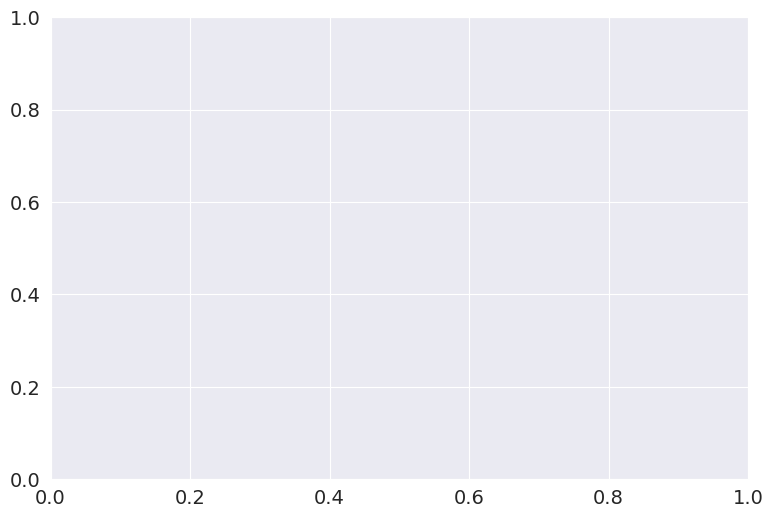

In [8]:

fig, ax = plt.subplots(1, figsize=(9, 6))

condition_palette = dict()

for cond in plot_mean_migration_speeds["condition_color"].unique():
    if "green" in cond:
        condition_palette[cond] = "limegreen"
    elif "red" in cond:
        condition_palette[cond] = "violet"
    #else:
    #    condition_palette[cond] = "red"

#sns.color_palette("husl", len(plot_mean_migration_speeds["condition_color"].unique()))

properties_dabest = dabest.load(data=plot_mean_migration_speeds, x="condition_color", y="vel_x_mu_per_h",
                                idx=('Stat-siRNA_black', 'Flow-siRNA_black'))

#properties_dabest = dabest.load(data = plot_other_df, x="CONDITION", y="clustering",
#
#                           idx=(( 'mosaic_siCTRL_siCTRL',  'mosaic_siCTRL_siSMAD4',  'mosaic_siCTRL_siAlk1')))

print(properties_dabest.mean_diff)
display(properties_dabest.mean_diff.results)

#properties_dabest = dabest.load(data = summary_data_CTR, x="time_interval", y="labelled_arterial_ECs",
#                          idx=('P8_P9', 'P5_P6', 'P5_P7', 'P5_P8', 'P5_P9'))

# Produce a Cumming estimation plot.
#test = properties_dabest.mean_diff.plot(swarm_ylim=(0, 10), contrast_ylim=(-3, 2));
#test = properties_dabest.mean_diff.plot(swarm_ylim=swarm_ylim, custom_palette = time_condition_palette) #, contrast_ylim=(-4, 2));
test = properties_dabest.mean_diff.plot(ax=ax, custom_palette=condition_palette)
test.savefig(output_folder + "mean_velocity_parallel_to_flow.pdf")
test.savefig(output_folder + "mean_velocity_parallel_to_flow.png")

IndexError: "mosaic_siScr_siScr_green" is not a group in the column `condition_color`. Please check `idx` and try again.

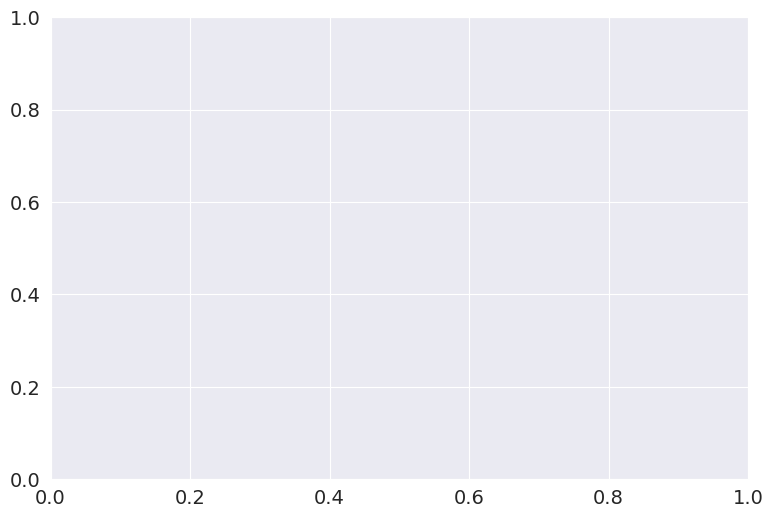

In [9]:

fig, ax = plt.subplots(1, figsize=(9, 6))

condition_palette = dict()

for cond in plot_mean_migration_speeds["condition_color"].unique():
    if "green" in cond:
        condition_palette[cond] = "limegreen"
    elif "red" in cond:
        condition_palette[cond] = "violet"
    #else:
    #    condition_palette[cond] = "red"

#sns.color_palette("husl", len(plot_mean_migration_speeds["condition_color"].unique()))

properties_dabest = dabest.load(data=plot_mean_migration_speeds, x="condition_color", y="vel_mu_per_h",
                                idx=(('mosaic_siScr_siScr_green', 'mosaic_siScr_siScr_red'),
                                     ('mosaic_siScr_siCdc42_green', 'mosaic_siScr_siCdc42_red'),
                                     ('mosaic_siScr_siRac1_green', 'mosaic_siScr_siRac1_red')))

#properties_dabest = dabest.load(data = plot_other_df, x="CONDITION", y="clustering",
#
#                           idx=(( 'mosaic_siCTRL_siCTRL',  'mosaic_siCTRL_siSMAD4',  'mosaic_siCTRL_siAlk1')))

print(properties_dabest.mean_diff)
display(properties_dabest.mean_diff.results)

#properties_dabest = dabest.load(data = summary_data_CTR, x="time_interval", y="labelled_arterial_ECs",
#                          idx=('P8_P9', 'P5_P6', 'P5_P7', 'P5_P8', 'P5_P9'))

# Produce a Cumming estimation plot.
#test = properties_dabest.mean_diff.plot(swarm_ylim=(0, 10), contrast_ylim=(-3, 2));
#test = properties_dabest.mean_diff.plot(swarm_ylim=swarm_ylim, custom_palette = time_condition_palette) #, contrast_ylim=(-4, 2));
test = properties_dabest.mean_diff.plot(ax=ax, custom_palette=condition_palette)
test.savefig(output_folder + "mean_velocity.pdf")
test.savefig(output_folder + "mean_velocity.png")